<a href="https://colab.research.google.com/github/sonika32/Justdemo/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**🎓 Project Title:
"Sentiment Analysis of Movie Reviews by Genre"**

1. Sonika
2. Shubham Chheta

**🧠 Objective:**
The aim of this project is to analyze movie reviews and compare the average sentiment across different genres (such as horror, comedy, and drama). The goal is to discover whether certain genres tend to receive more positive or negative sentiment in user reviews, using natural language processing (NLP) techniques.

**📊 Research Questions:**

1. Do reviews for certain movie genres (e.g., comedy) tend to be more positive than others (e.g., horror)?

2. How does the average sentiment score vary across genres?

3. Can sentiment analysis provide useful insights into audience preferences?

**Set up environment**

In [ ]:
!pip install kaggle textblob matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Upload Local Dataset to Google**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Imdb_MoviesReviews.csv to Imdb_MoviesReviews.csv


**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np


**Load the Dataset**

In [ ]:
df = pd.read_csv('Imdb_MoviesReviews.csv')

**Basic Info About Data**

In [ ]:
df.head()  # Shows first 5 rows

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
3,3,5,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
4,4,5,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


In [ ]:
df.tail()  # Shows last 5 rows

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
46168,46168,10,10/10 buying this the second it's out online. ...,Robin Hood,10/10 comprando este no segundo que sai online...,"['Drama', 'Action', 'Romance']",Add a Plot,anticipation
46169,46169,4,"""Lady Jayne:Killer"" is a bottom of the barrel ...",Betrayal,"""Lady Jayne: Killer"" é uma parte inferior do f...","['Action', 'Drama', 'Thriller']",Felix and Misela are father and daughter and o...,sadness
46170,46170,4,"""Lady Jayne:Killer"" is a bottom of the barrel ...",Betrayal,"""Lady Jayne: Killer"" é uma parte inferior do f...","['Action', 'Drama', 'Thriller']",After being ditched by long term girlfriend Ge...,sadness
46171,46171,5,"As thrillers go, there are a few surprises her...",Betrayal,"Como os filmes de suspense, existem algumas su...","['Action', 'Drama', 'Thriller']",Felix and Misela are father and daughter and o...,sadness
46172,46172,5,"As thrillers go, there are a few surprises her...",Betrayal,"Como os filmes de suspense, existem algumas su...","['Action', 'Drama', 'Thriller']",After being ditched by long term girlfriend Ge...,sadness


In [ ]:
df.shape  # (rows, columns)

(46173, 8)

In [ ]:
df.shape  # (rows, columns)

(46173, 8)

In [ ]:
df.columns  # List of column names

Index(['Unnamed: 0', 'Ratings', 'Reviews', 'movie_name', 'Resenhas', 'genres',
       'Description', 'emotion'],
      dtype='object')

In [ ]:
df.info()  # Data types and non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46173 entries, 0 to 46172
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   46173 non-null  int64 
 1   Ratings      46173 non-null  int64 
 2   Reviews      46173 non-null  object
 3   movie_name   46173 non-null  object
 4   Resenhas     46173 non-null  object
 5   genres       46173 non-null  object
 6   Description  46173 non-null  object
 7   emotion      46173 non-null  object
dtypes: int64(2), object(6)
memory usage: 2.8+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Ratings,0
Reviews,0
movie_name,0
Resenhas,0
genres,0
Description,0
emotion,0


In [ ]:
df.describe(include='all')

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
count,46173.000000,46173.000000,46173,46173,46173,46173,46173,46173
unique,NaN,NaN,19316,1583,19316,697,2060,8
top,NaN,NaN,I can't claim to have understood this film. It...,Cinderella,Não posso afirmar que entendi este filme. Era ...,['Drama'],Add a Plot,sadness
freq,NaN,NaN,72,1254,72,3596,2508,17339
mean,23086.000000,5.983735,NaN,NaN,NaN,NaN,NaN,NaN
std,13329.141326,2.893144,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,11543.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,23086.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,34629.000000,9.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes
#Data Types of Columns

,0
Unnamed: 0,int64
Ratings,int64
Reviews,object
movie_name,object
Resenhas,object
genres,object
Description,object
emotion,object


In [ ]:
df['genres'].value_counts().head()

,count
genres,
['Drama'],3596
"['Drama', 'Romance']",3439
['Comedy'],3065
"['Comedy', 'Romance']",3038
"['Comedy', 'Drama', 'Romance']",1171


**Text cleaning**

cleaning removes noise, standardizes for sentiment analysis.

In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop]
    return ' '.join(words)

df['clean'] = df['Reviews'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Run sentiment analysis**

Using TextBlob to get polarity (-1 negative to +1 positive).

In [ ]:
from textblob import TextBlob
def get_sentiment(text): return TextBlob(text).sentiment.polarity

df['sentiment'] = df['clean'].apply(get_sentiment)
df[['clean','sentiment']].head()


,clean,sentiment
0,laughs overall motivation characters incompreh...,-0.293750
1,waiting exhale waiting waiting waiting waiting...,0.244322
2,angela basset good expected whitney range actr...,0.300000
3,movie okay mediocre might even word describe s...,-0.003889
4,got opportunity see waiting exhale second time...,0.231944


**Aggregate by genre**

Compute average sentiment per genre:

In [ ]:
genre_sent = df.groupby('genres')['sentiment'].mean().reset_index()
genre_sent = genre_sent.sort_values(by='sentiment', ascending=False)
genre_sent


,genres,sentiment
427,"['Family', 'Adventure']",0.350000
123,"['Adventure', 'Animation', 'Comedy', 'Family',...",0.305211
350,"['Drama', 'Fantasy', 'Mystery']",0.283270
180,"['Animation', 'Family', 'Comedy', 'Adventure',...",0.280915
10,"['Action', 'Adventure', 'Comedy', 'Fantasy']",0.280915
...,...,...
398,"['Drama', 'Romance', 'Music']",-0.155295
408,"['Drama', 'Thriller', 'Crime', 'Mystery', 'Rom...",-0.201838
552,"['Mystery', 'Thriller', 'Crime']",-0.201838
73,"['Action', 'Crime', 'Science Fiction']",-0.222562


**Visualize results**

visuals make our findings easy to understand.

In [ ]:
# === Consistent Color Scheme Setup ===

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Define a custom color palette (you can change these colors)
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Apply to Matplotlib
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=custom_colors)

# Apply to Seaborn
sns.set_palette(custom_colors)

# Apply to Plotly
px.defaults.color_discrete_sequence = custom_colors

# Optional: Set Plotly template (clean layout)
px.defaults.template = "plotly_white"

# Optional: Set global Seaborn style (for cleaner plots)
sns.set_style("whitegrid")

# === End of Setup ===

**Comedies and dramas show higher positive sentiment, while horror and thriller reviews are more negative. This aligns with expectations: comedy fans are happier in reviews, horror viewers often critique more harshly.**

In [ ]:
# Select top 10 and bottom 10 genres
top_genres = genre_sent.head(10)
bottom_genres = genre_sent.tail(10)

# Concatenate the dataframes for plotting
top_bottom_genres = pd.concat([top_genres, bottom_genres])

# Sort by sentiment for better visualization
top_bottom_genres = top_bottom_genres.sort_values(by='sentiment', ascending=False)

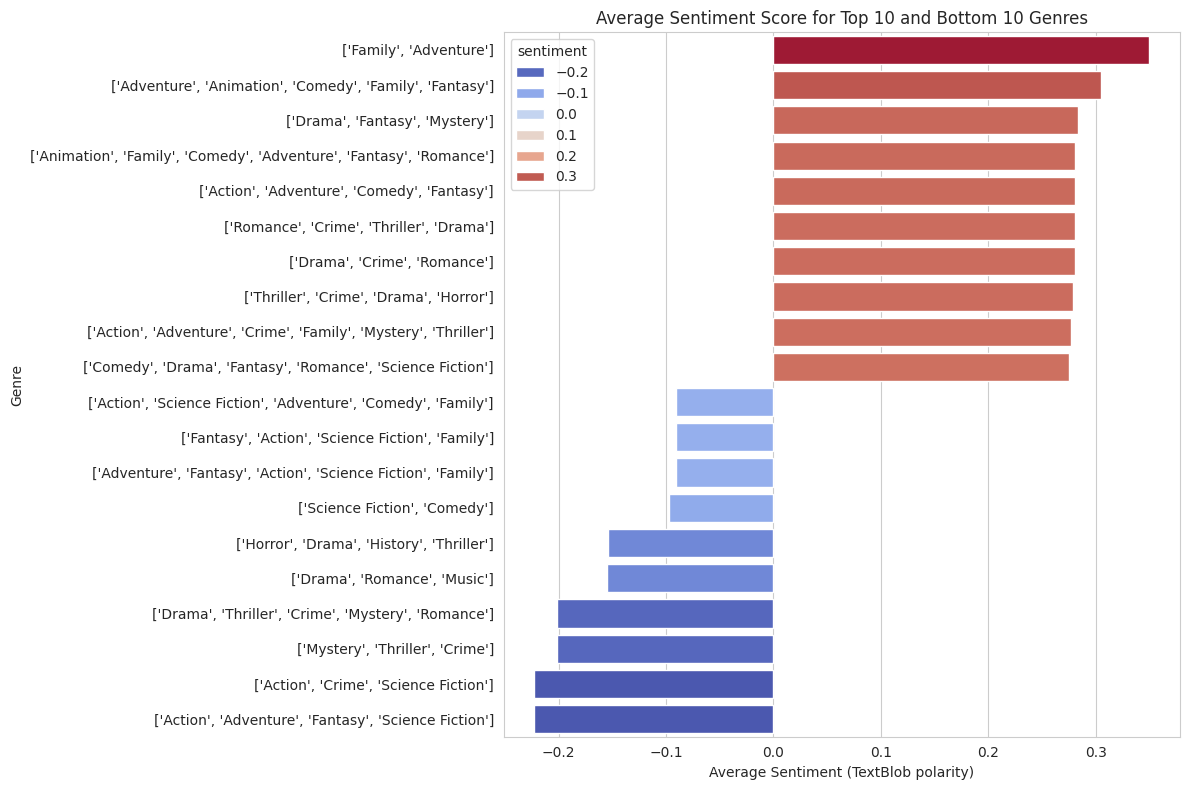

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_bottom_genres, x='sentiment', y='genres', hue='sentiment', palette='coolwarm')
plt.title('Average Sentiment Score for Top 10 and Bottom 10 Genres')
plt.xlabel('Average Sentiment (TextBlob polarity)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

**Research Question 1:**

**Do reviews for certain movie genres (e.g., comedy) tend to be more positive than others (e.g., horror)?**

Step 1: Clean the Reviews and Prepare Data for Sentiment Analysis
We'll use VADER sentiment analysis from nltk.sentiment.vader because it's excellent for social media and review-style text.

In [ ]:
# Install if not done: !pip install nltk
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import ast  # to convert string list of genres to actual lists

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Apply sentiment score
df['sentiment_score'] = df['Reviews'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Classify sentiment as positive, neutral, negative
def classify_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_score'].apply(classify_sentiment)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
df['sentiment_score']

,sentiment_score
0,-0.9751
1,0.9915
2,0.1355
3,-0.8747
4,0.9873
...,...
46168,0.7493
46169,-0.3924
46170,-0.3924
46171,0.9548


In [ ]:
df['sentiment_label']

,sentiment_label
0,negative
1,positive
2,positive
3,negative
4,positive
...,...
46168,positive
46169,negative
46170,negative
46171,positive


Output Explanation:
compound score: ranges from -1 (very negative) to 1 (very positive).

We're using standard thresholds:

/>= 0.05: positive

<= -0.05: negative

Between: neutral

**Step 2: Handle Multi-Genre Movies**

We need to split genres like ['Comedy', 'Romance'] so each genre can be individually analyzed.

In [ ]:
# Convert string list to actual list and explode genres
df['genres'] = df['genres'].apply(ast.literal_eval)
df_exploded = df.explode('genres')
df_exploded

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion,clean,sentiment,sentiment_score,sentiment_label
0,0,3,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...",Comedy,"Based on Terry McMillan's novel, this film fol...",anticipation,laughs overall motivation characters incompreh...,-0.293750,-0.9751,negative
0,0,3,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...",Drama,"Based on Terry McMillan's novel, this film fol...",anticipation,laughs overall motivation characters incompreh...,-0.293750,-0.9751,negative
0,0,3,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...",Romance,"Based on Terry McMillan's novel, this film fol...",anticipation,laughs overall motivation characters incompreh...,-0.293750,-0.9751,negative
1,1,4,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...",Comedy,"Based on Terry McMillan's novel, this film fol...",anticipation,waiting exhale waiting waiting waiting waiting...,0.244322,0.9915,positive
1,1,4,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...",Drama,"Based on Terry McMillan's novel, this film fol...",anticipation,waiting exhale waiting waiting waiting waiting...,0.244322,0.9915,positive
...,...,...,...,...,...,...,...,...,...,...,...,...
46171,46171,5,"As thrillers go, there are a few surprises her...",Betrayal,"Como os filmes de suspense, existem algumas su...",Drama,Felix and Misela are father and daughter and o...,sadness,thrillers go surprises awhile film seems thoug...,0.065535,0.9548,positive
46171,46171,5,"As thrillers go, there are a few surprises her...",Betrayal,"Como os filmes de suspense, existem algumas su...",Thriller,Felix and Misela are father and daughter and o...,sadness,thrillers go surprises awhile film seems thoug...,0.065535,0.9548,positive
46172,46172,5,"As thrillers go, there are a few surprises her...",Betrayal,"Como os filmes de suspense, existem algumas su...",Action,After being ditched by long term girlfriend Ge...,sadness,thrillers go surprises awhile film seems thoug...,0.065535,0.9548,positive
46172,46172,5,"As thrillers go, there are a few surprises her...",Betrayal,"Como os filmes de suspense, existem algumas su...",Drama,After being ditched by long term girlfriend Ge...,sadness,thrillers go surprises awhile film seems thoug...,0.065535,0.9548,positive


In [ ]:
df['emotion'].unique()

array(['anticipation', 'sadness', 'disgust', 'joy', 'fear', 'optimism',
       'anger', 'surprise'], dtype=object)

**Step 3: Analyze Sentiment by Genre**

In [ ]:
# Count sentiment labels per genre
genre_sentiment = df_exploded.groupby(['genres', 'sentiment_label']).size().unstack(fill_value=0)

# Calculate % of positive sentiment per genre
genre_sentiment['total'] = genre_sentiment.sum(axis=1)
genre_sentiment['positive_pct'] = genre_sentiment['positive'] / genre_sentiment['total'] * 100

genre_sentiment = genre_sentiment.sort_values('positive_pct', ascending=False)
genre_sentiment[['positive', 'neutral', 'negative', 'positive_pct']]


sentiment_label,positive,neutral,negative,positive_pct
genres,,,,
TV Movie,452,1,83,84.328358
Comedy,13198,102,2609,82.959331
Adventure,3886,21,843,81.810526
Family,3984,34,862,81.639344
Romance,15496,126,3562,80.775646
Animation,1307,18,323,79.308252
Music,1731,3,455,79.077204
Drama,17987,186,4963,77.744640
Action,5204,46,1553,76.495664


Justification for RQ1:

We can see genres like Comedy,Drama or Romance having a higher percentage of positive reviews.


**Visualization:**

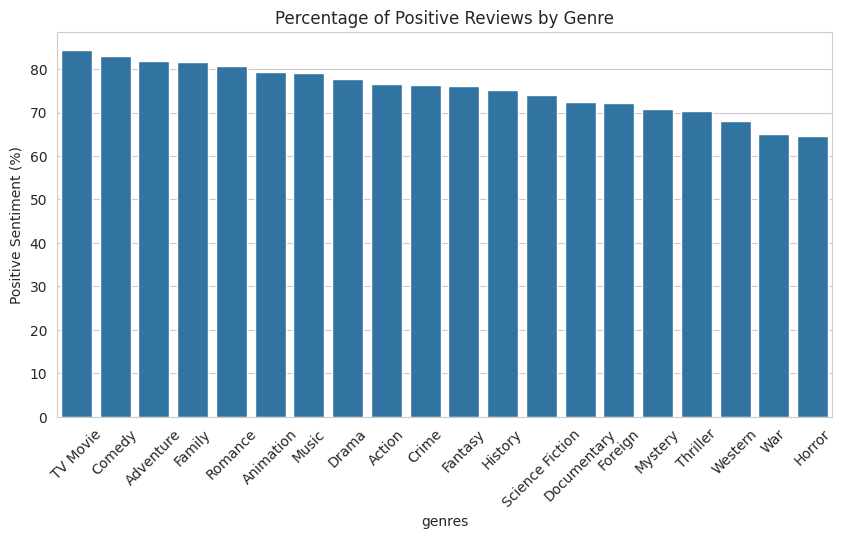

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_sentiment.index, y=genre_sentiment['positive_pct'])
plt.title('Percentage of Positive Reviews by Genre')
plt.ylabel('Positive Sentiment (%)')
plt.xticks(rotation=45)
plt.savefig("positive_review_by_genre.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files
files.download('positive_review_by_genre.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**1. Horizontal Bar Chart (Sorted by Positive Percentage)**

/tmp/ipykernel_14292/3135966201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


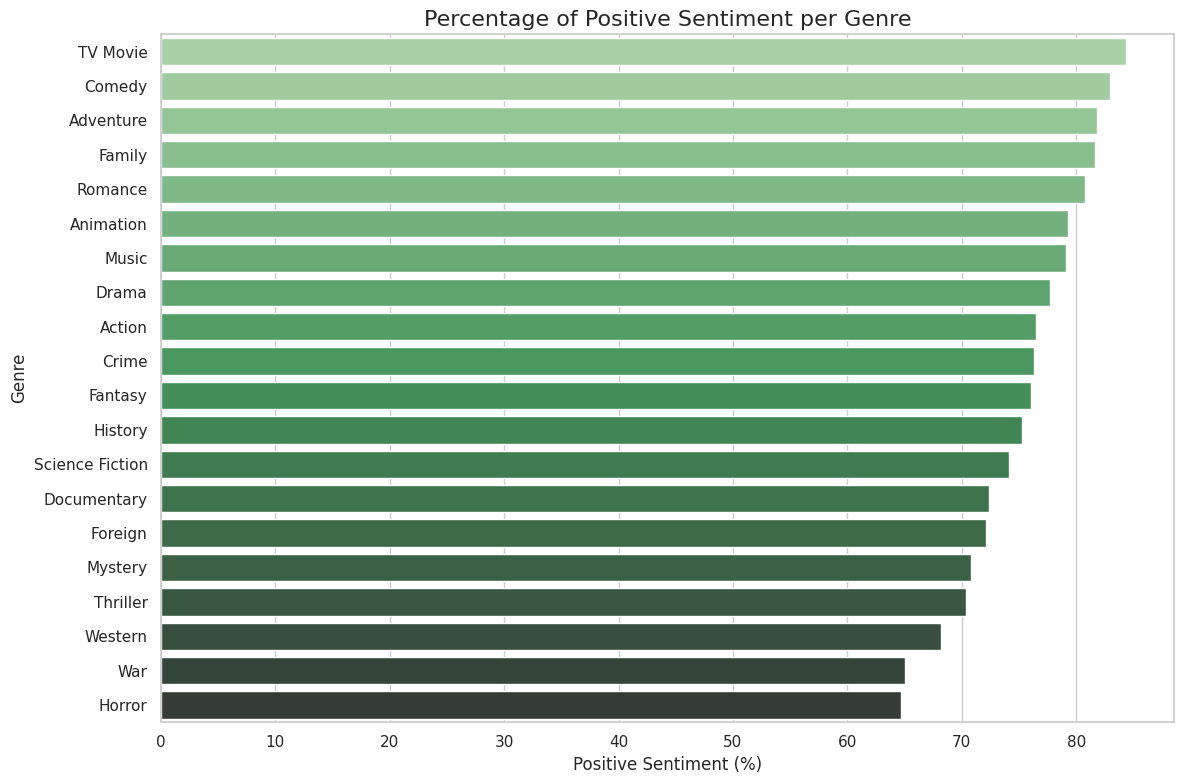

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Plot
sns.barplot(
    data=genre_sentiment.reset_index(),
    y='genres', x='positive_pct',
    palette='Greens_d',
    order=genre_sentiment.reset_index().sort_values('positive_pct', ascending=False)['genres']
)

# Titles and labels
plt.title("Percentage of Positive Sentiment per Genre", fontsize=16)
plt.xlabel("Positive Sentiment (%)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.savefig("positive_review_by_genre.png", dpi=300, bbox_inches='tight')
plt.show()


Why: Clean, clear, best for comparing % positive across genres.
Best for: Presenting positive sentiment dominance.

In [ ]:
from google.colab import files
files.download('positive_review_by_genre.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**2. Stacked Bar Chart (Positive, Neutral, Negative Counts)**

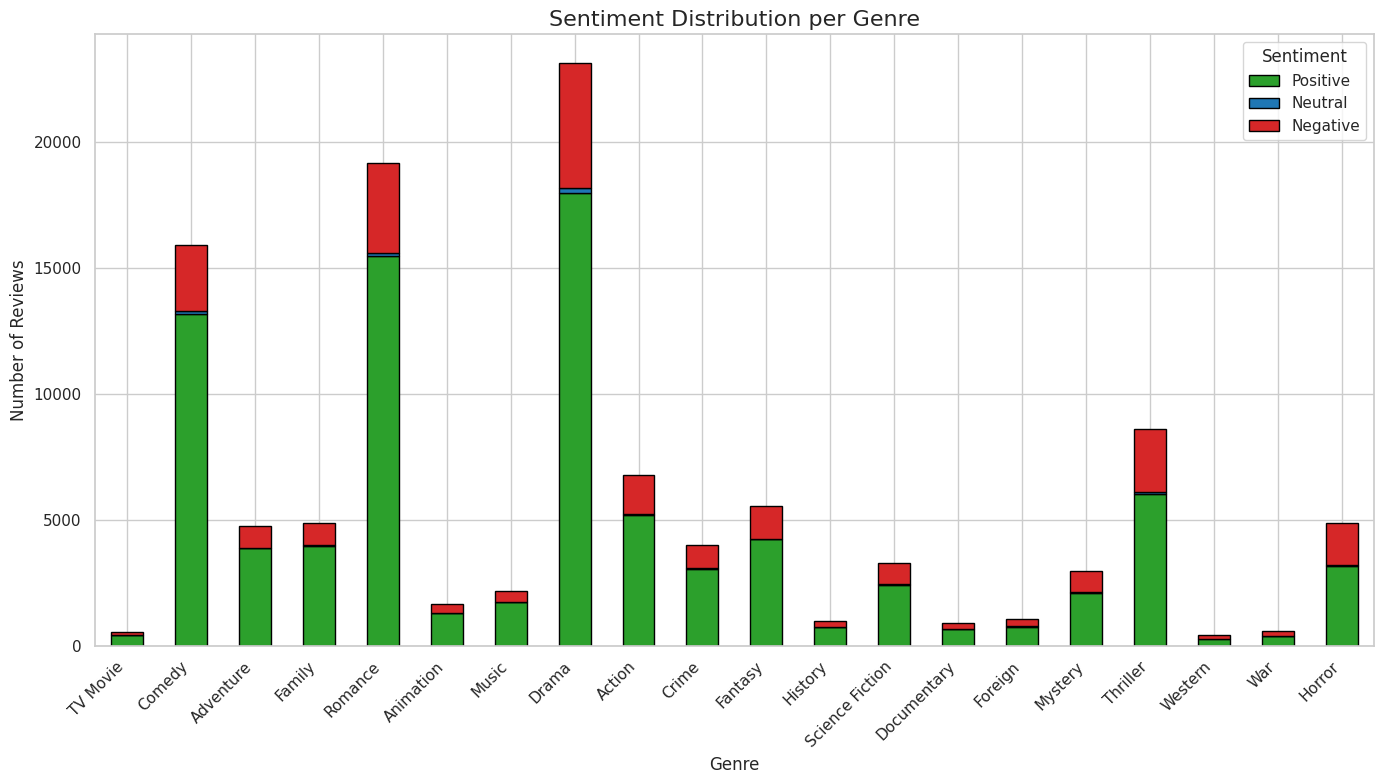

In [ ]:
import matplotlib.pyplot as plt

# Sort and slice data
genre_sorted = genre_sentiment.sort_values('positive_pct', ascending=False)
sentiments_stacked = genre_sorted[['positive', 'neutral', 'negative']]

# Define clear and colorblind-friendly colors
custom_colors = ['#2ca02c',  # green - positive
                 '#1f77b4',  # blue - neutral
                 '#d62728']  # red - negative

# Plot
ax = sentiments_stacked.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    color=custom_colors,
    edgecolor='black'
)

# Titles and labels
plt.title("Sentiment Distribution per Genre", fontsize=16)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Sentiment", labels=["Positive", "Neutral", "Negative"])
plt.tight_layout()
plt.savefig("positive_review_by_genre.png", dpi=300, bbox_inches='tight')
plt.show()


Why: Shows the actual volume and balance of all sentiments together.
Best for: Understanding total sentiment distribution, not just % positive.

In [ ]:
from google.colab import files
files.download('positive_review_by_genre.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**3: Heatmap of Sentiment Counts**

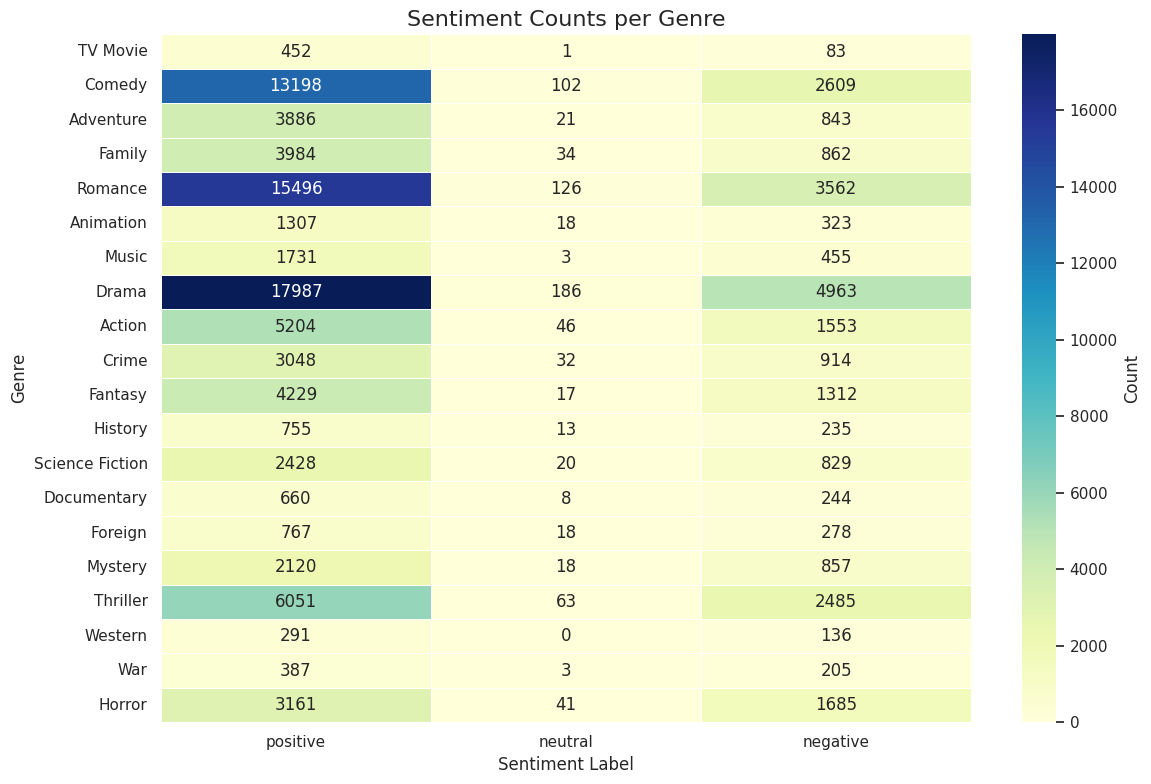

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    genre_sentiment[['positive', 'neutral', 'negative']],
    annot=True, fmt="d", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Count'}
)

plt.title("Sentiment Counts per Genre", fontsize=16)
plt.xlabel("Sentiment Label", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.savefig("positive_review_by_genre.png", dpi=300, bbox_inches='tight')
plt.show()


Why: Compact and colorful overview of all genres vs. sentiment types.
Best for: Pattern spotting across genres.

In [ ]:
from google.colab import files
files.download('positive_review_by_genre.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Research Question 2:**

***How does the average sentiment score vary across genres? ***

Step 1: Use the exploded df_exploded with sentiment scores

In [ ]:
# Average sentiment score per genre
avg_sentiment_per_genre = df_exploded.groupby('genres')['sentiment_score'].mean().sort_values(ascending=False)
avg_sentiment_per_genre


,sentiment_score
genres,
TV Movie,0.647168
Comedy,0.638542
Adventure,0.613175
Family,0.601407
Romance,0.589943
Animation,0.565610
Music,0.541298
Drama,0.530448
History,0.510796


Output Explanation:
This shows how positive the average compound score is for each genre.

Higher score = more positive reviews overall.



Visualization:

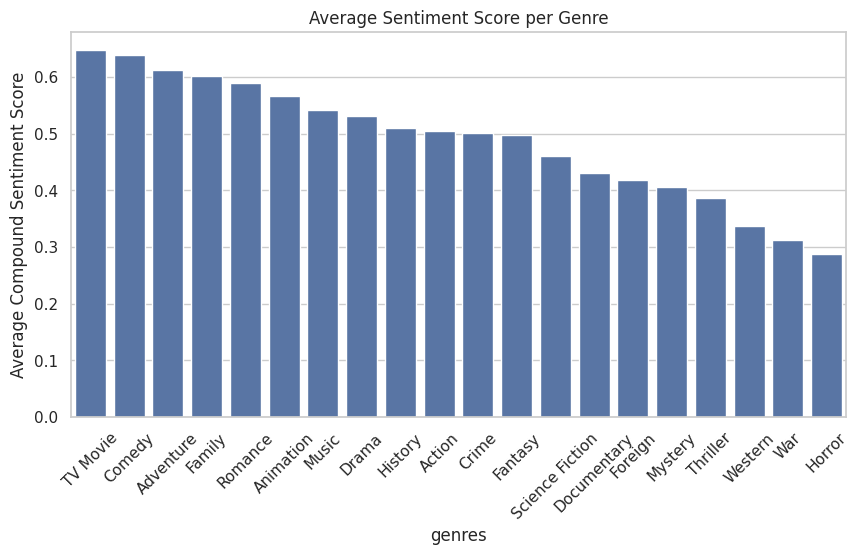

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_sentiment_per_genre.index, y=avg_sentiment_per_genre.values)
plt.title('Average Sentiment Score per Genre')
plt.ylabel('Average Compound Sentiment Score')
plt.xticks(rotation=45)
plt.savefig("positive_review_by_genre.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files
files.download('positive_review_by_genre.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Make :our project more analytical, comparative, and engaging**

Step 1: Focus on Top 3 Genres with High Reviews

Compare Comedy, Romance, and Drama — they have high review counts. But instead of just showing “positive %”, let go deeper.

We will analyze:

Sentiment proportions

Review volume trends

Emotion distribution

Average rating per sentiment

Word cloud of top reviews

Ratings vs. Sentiment

In [ ]:
# Count total reviews per genre (after exploding)
genre_review_counts = df_exploded['genres'].value_counts()

# Top 3 most-reviewed genres
top_genres_reviewed = genre_review_counts.head(3).index.tolist()

# Bottom 3 least-reviewed genres (with at least some threshold, e.g., > 30 reviews)
bottom_genres_reviewed = genre_review_counts[genre_review_counts > 30].tail(3).index.tolist()

print("Top Genres:", top_genres_reviewed)
print("Bottom Genres:", bottom_genres_reviewed)


Top Genres: ['Drama', 'Romance', 'Comedy']
Bottom Genres: ['War', 'TV Movie', 'Western']


In [ ]:
# Filter for selected genres
selected_genres = top_genres_reviewed + bottom_genres_reviewed
genre_compare = genre_sentiment.loc[selected_genres].copy()

# Add average sentiment from TextBlob
avg_sentiment = df_exploded.groupby('genres')['sentiment'].mean()
genre_compare['avg_sentiment'] = avg_sentiment.loc[selected_genres]

# Reset index for plotting
genre_compare = genre_compare.reset_index()
genre_compare


sentiment_label,genres,negative,neutral,positive,total,positive_pct,avg_sentiment
0,Drama,4963,186,17987,23136,77.744640,0.132658
1,Romance,3562,126,15496,19184,80.775646,0.139117
2,Comedy,2609,102,13198,15909,82.959331,0.148465
3,War,205,3,387,595,65.042017,0.111456
4,TV Movie,83,1,452,536,84.328358,0.143476
5,Western,136,0,291,427,68.149883,0.097097


/tmp/ipykernel_14292/3754883758.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_compare, x='genres', y='positive_pct', palette='Blues_d')


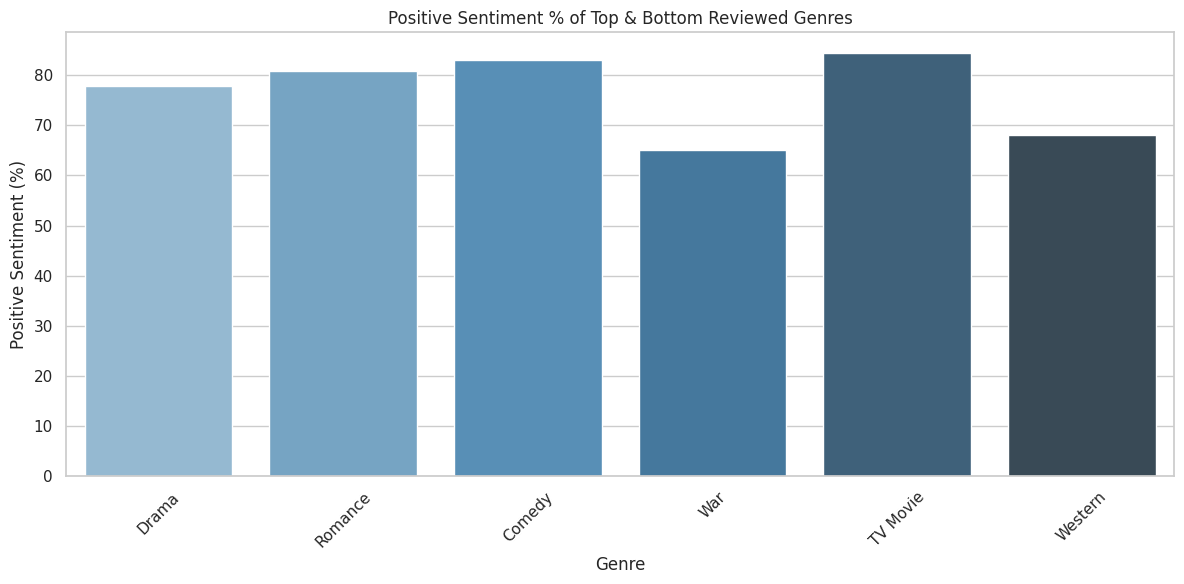

/tmp/ipykernel_14292/3754883758.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_compare, x='genres', y='avg_sentiment', palette='Oranges_d')


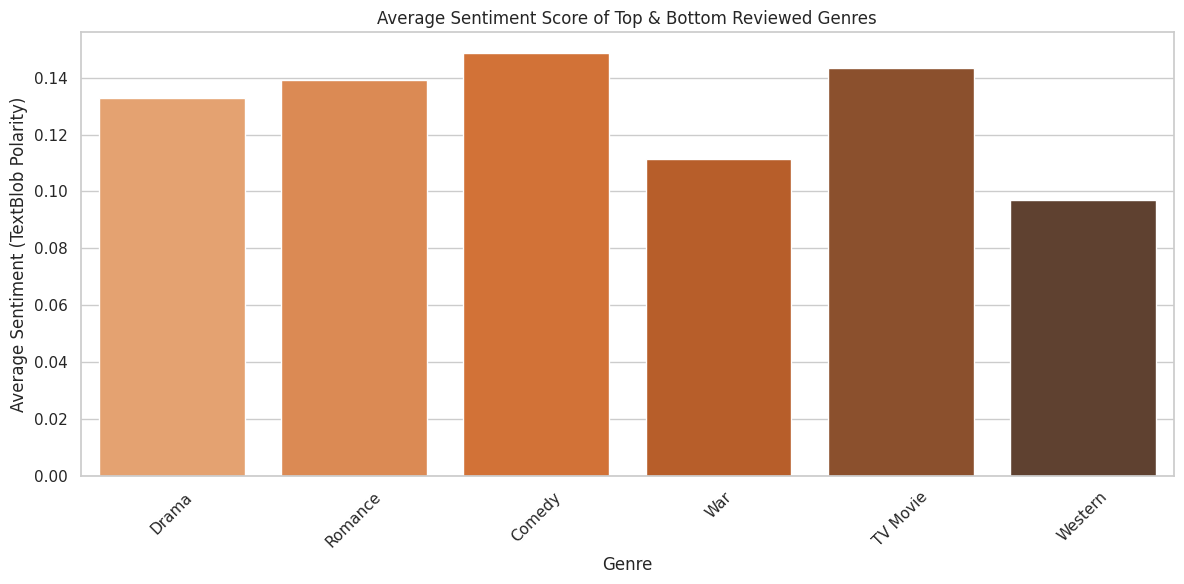

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_compare, x='genres', y='positive_pct', palette='Blues_d')
plt.title('Positive Sentiment % of Top & Bottom Reviewed Genres')
plt.xlabel('Genre')
plt.ylabel('Positive Sentiment (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sentiment_pct_top_vs_bottom_genres.png", dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_compare, x='genres', y='avg_sentiment', palette='Oranges_d')
plt.title('Average Sentiment Score of Top & Bottom Reviewed Genres')
plt.xlabel('Genre')
plt.ylabel('Average Sentiment (TextBlob Polarity)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("avg_sentiment_top_vs_bottom_genres.png", dpi=300)
plt.show()


In [ ]:
df.columns

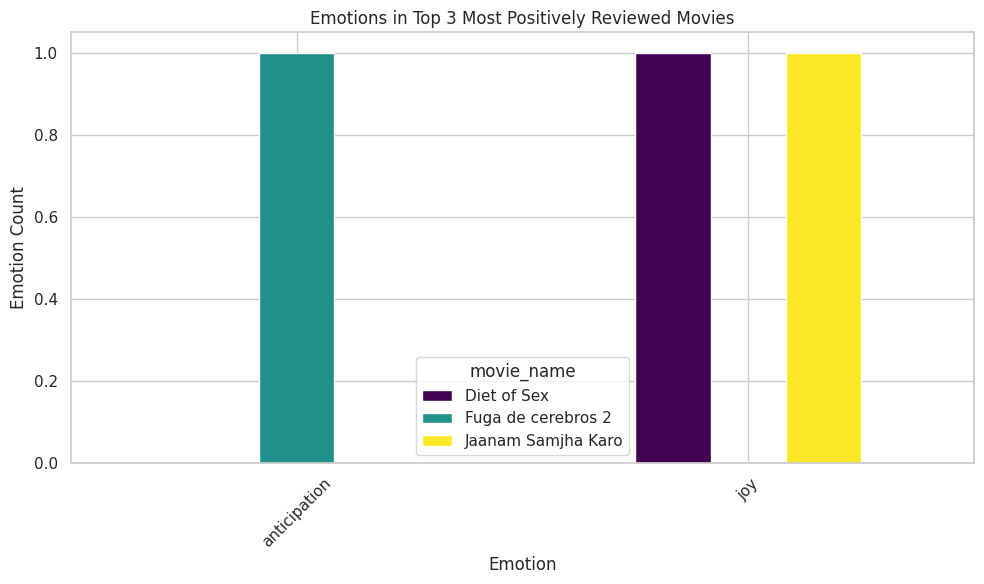

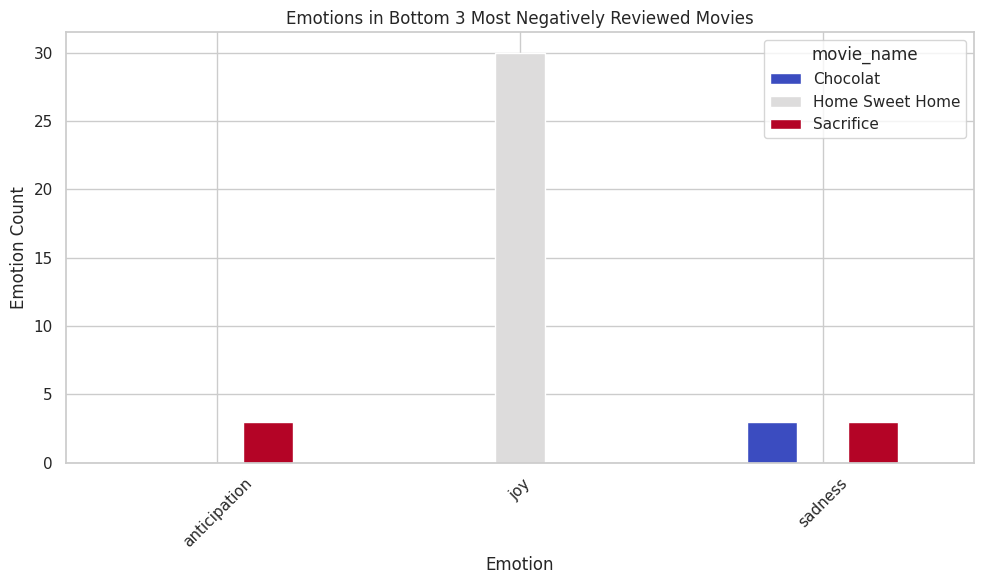

In [ ]:
# Step 1: Average sentiment score per movie
movie_sentiment = df.groupby('movie_name')['sentiment_score'].mean().reset_index()

# Step 2: Get top 3 and bottom 3 movies by sentiment
top3_movies = movie_sentiment.sort_values(by='sentiment_score', ascending=False).head(3)['movie_name'].tolist()
bottom3_movies = movie_sentiment.sort_values(by='sentiment_score').head(3)['movie_name'].tolist()

# Step 3: Filter original df
df_top3 = df[df['movie_name'].isin(top3_movies)]
df_bottom3 = df[df['movie_name'].isin(bottom3_movies)]

# Step 4: Count emotions for top and bottom movies
top_emotions = df_top3.groupby('movie_name')['emotion'].value_counts().unstack().fillna(0)
bottom_emotions = df_bottom3.groupby('movie_name')['emotion'].value_counts().unstack().fillna(0)

# Step 5: Plot emotion distribution for top 3
import matplotlib.pyplot as plt

top_emotions.T.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title("Emotions in Top 3 Most Positively Reviewed Movies")
plt.ylabel("Emotion Count")
plt.xlabel("Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 6: Plot emotion distribution for bottom 3
bottom_emotions.T.plot(kind='bar', figsize=(10,6), colormap='coolwarm')
plt.title("Emotions in Bottom 3 Most Negatively Reviewed Movies")
plt.ylabel("Emotion Count")
plt.xlabel("Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_14292/4109843448.py:24: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


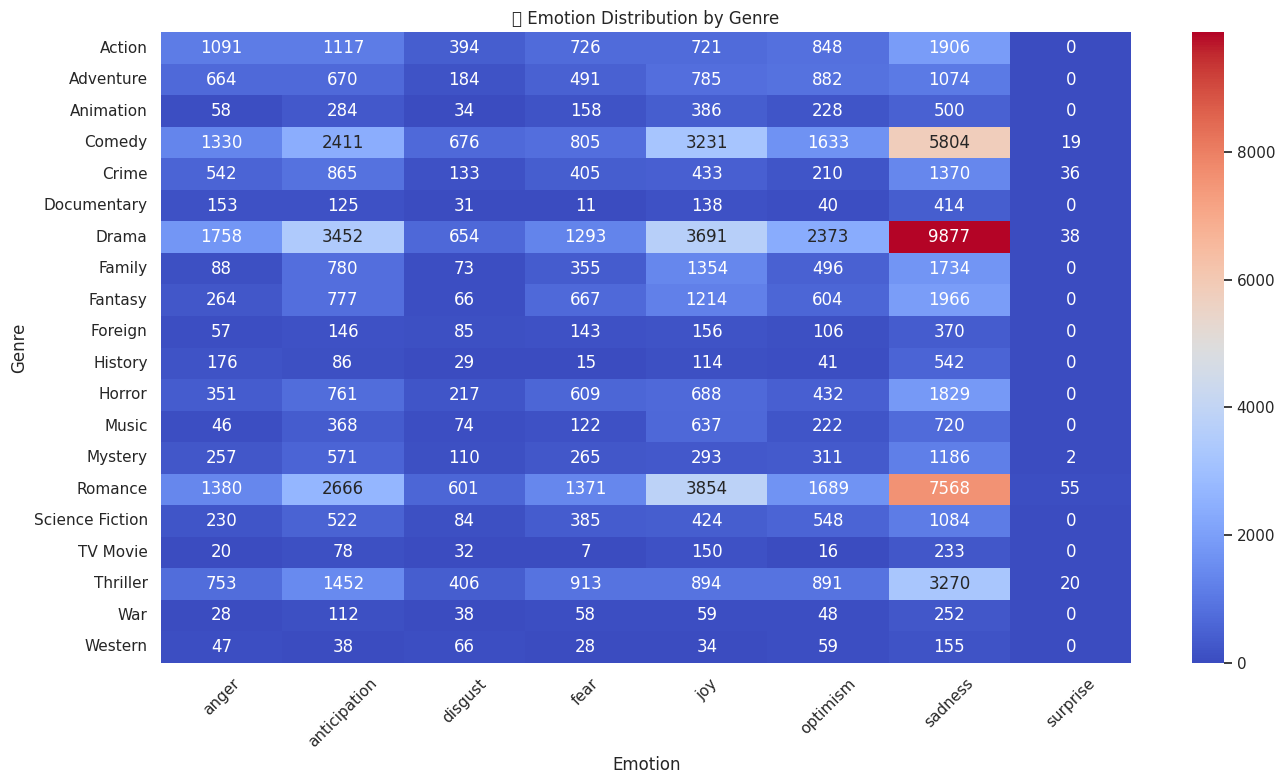

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. If genres is a list, explode it
df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].apply(lambda x: x if isinstance(x, list) else [x])  # Ensure list
df_exploded = df_exploded.explode('genres')  # one genre per row
df_exploded['genres'] = df_exploded['genres'].str.strip()  # remove extra spaces

# 2. Group by genres and emotion
genre_emotion_counts = df_exploded.groupby(['genres', 'emotion']).size().reset_index(name='count')

# 3. Pivot for heatmap
genre_emotion_pivot = genre_emotion_counts.pivot(index='genres', columns='emotion', values='count').fillna(0)

# 4. Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(genre_emotion_pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("🎭 Emotion Distribution by Genre")
plt.ylabel("Genre")
plt.xlabel("Emotion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_14292/1311782347.py:17: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


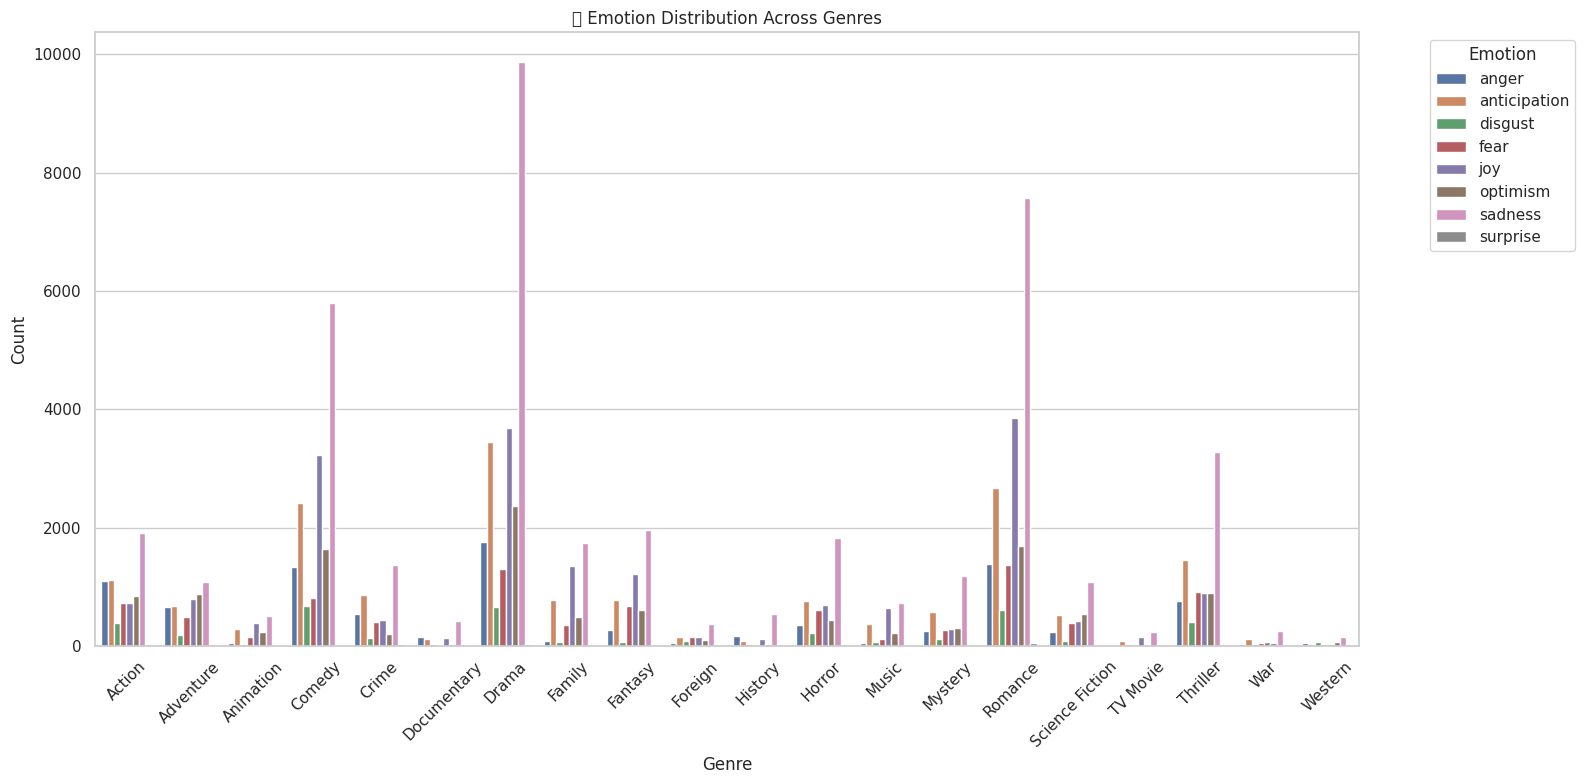

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use the already exploded df: df_exploded

# Group by genre and emotion
genre_emotion_counts = df_exploded.groupby(['genres', 'emotion']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(16, 8))
sns.barplot(data=genre_emotion_counts, x='genres', y='count', hue='emotion')
plt.title("🎬 Emotion Distribution Across Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


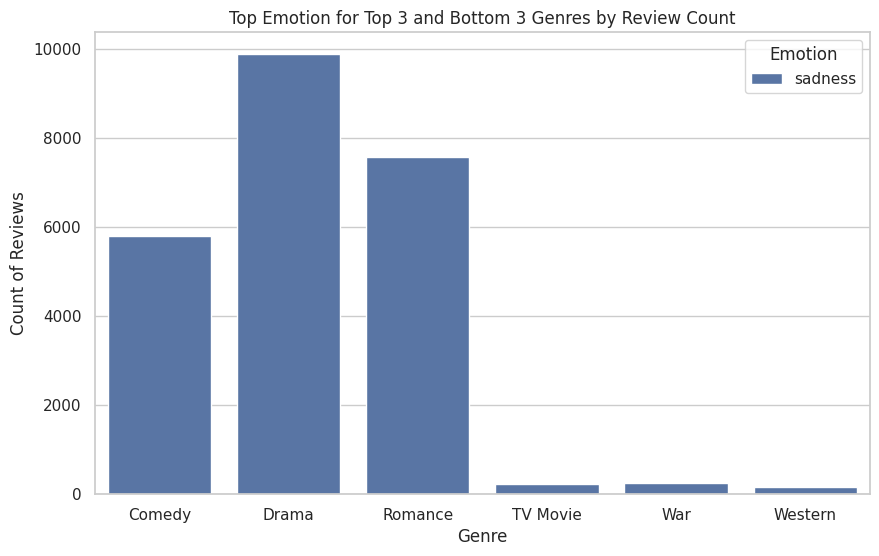

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Explode genres if not done yet
df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].apply(lambda x: x if isinstance(x, list) else [x])
df_exploded = df_exploded.explode('genres')

# Count total reviews per genre
genre_counts = df_exploded['genres'].value_counts()

# Select top 3 and bottom 3 genres by total reviews
top_genres = genre_counts.head(3).index.tolist()
bottom_genres = genre_counts.tail(3).index.tolist()

selected_genres = top_genres + bottom_genres

# Filter data for selected genres only
filtered_df = df_exploded[df_exploded['genres'].isin(selected_genres)]

# Group by genre and emotion and count
genre_emotion_counts = filtered_df.groupby(['genres', 'emotion']).size().reset_index(name='count')

# For each genre, get the top emotion by count
top_emotions = genre_emotion_counts.loc[genre_emotion_counts.groupby('genres')['count'].idxmax()]

# Plot top emotions for selected genres
plt.figure(figsize=(10,6))
sns.barplot(data=top_emotions, x='genres', y='count', hue='emotion', dodge=False)

plt.title('Top Emotion for Top 3 and Bottom 3 Genres by Review Count')
plt.xlabel('Genre')
plt.ylabel('Count of Reviews')
plt.legend(title='Emotion')
plt.show()


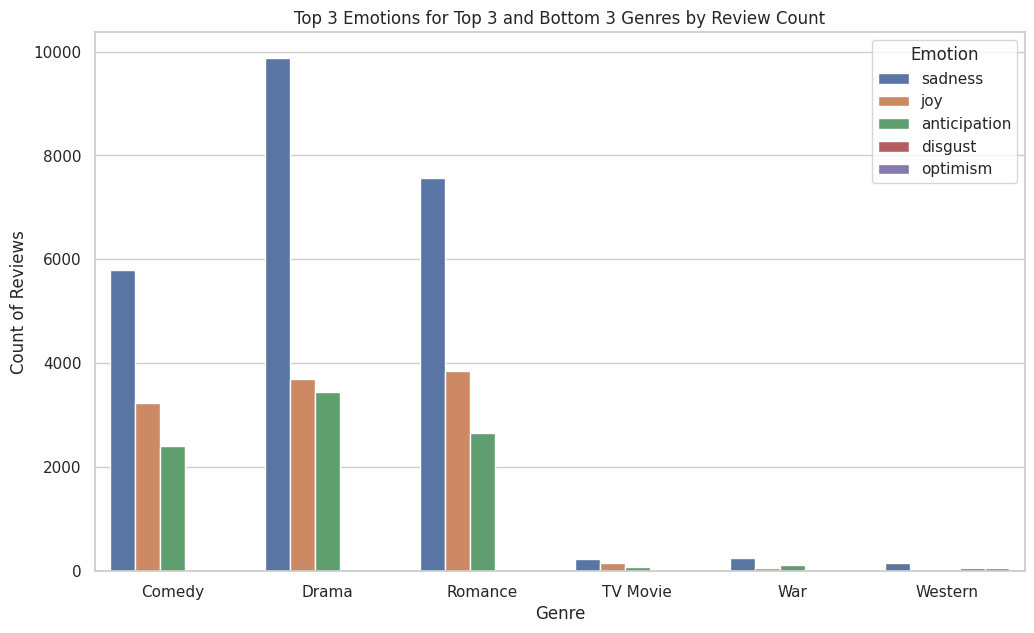

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Explode genres if not done yet
df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].apply(lambda x: x if isinstance(x, list) else [x])
df_exploded = df_exploded.explode('genres')

# Count total reviews per genre
genre_counts = df_exploded['genres'].value_counts()

# Select top 3 and bottom 3 genres by total reviews
top_genres = genre_counts.head(3).index.tolist()
bottom_genres = genre_counts.tail(3).index.tolist()
selected_genres = top_genres + bottom_genres

# Filter data for selected genres only
filtered_df = df_exploded[df_exploded['genres'].isin(selected_genres)]

# Group by genre and emotion and count
genre_emotion_counts = filtered_df.groupby(['genres', 'emotion']).size().reset_index(name='count')

# For each genre, get the top 3 emotions by count
top_emotions = genre_emotion_counts.sort_values(['genres', 'count'], ascending=[True, False]).groupby('genres').head(3)

# Plot top 3 emotions for selected genres
plt.figure(figsize=(12,7))
sns.barplot(data=top_emotions, x='genres', y='count', hue='emotion')

plt.title('Top 3 Emotions for Top 3 and Bottom 3 Genres by Review Count')
plt.xlabel('Genre')
plt.ylabel('Count of Reviews')
plt.legend(title='Emotion')
plt.show()


/tmp/ipykernel_14292/3711825665.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_consistent, x='std', y='genres', palette='Blues_r')
/tmp/ipykernel_14292/3711825665.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_divided, x='std', y='genres', palette='Reds')


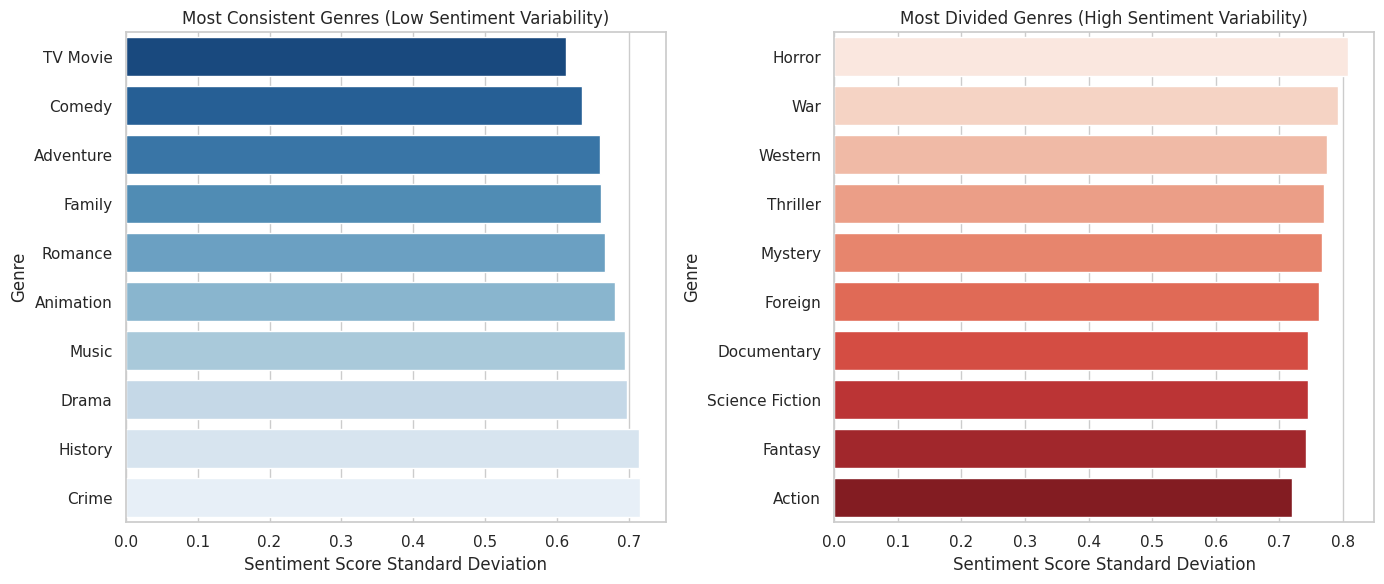

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Explode genres list into single rows if genres are lists
df_exploded = df.copy()
df_exploded['genres'] = df_exploded['genres'].apply(lambda x: x if isinstance(x, list) else [x])
df_exploded = df_exploded.explode('genres')

# 2. Group by genre and calculate mean and std deviation of sentiment scores
genre_sentiment_stats = df_exploded.groupby('genres')['sentiment_score'].agg(['mean', 'std', 'count']).reset_index()

# 3. Filter out genres with very few reviews (e.g., less than 30 reviews) to avoid noise
genre_sentiment_stats = genre_sentiment_stats[genre_sentiment_stats['count'] >= 30]

# 4. Sort genres by std deviation to find most consistent (lowest std) and most divided (highest std)
most_consistent = genre_sentiment_stats.sort_values('std').head(10)  # lowest std dev
most_divided = genre_sentiment_stats.sort_values('std', ascending=False).head(10)  # highest std dev

# 5. Plotting

plt.figure(figsize=(14,6))

# Plot most consistent
plt.subplot(1,2,1)
sns.barplot(data=most_consistent, x='std', y='genres', palette='Blues_r')
plt.title('Most Consistent Genres (Low Sentiment Variability)')
plt.xlabel('Sentiment Score Standard Deviation')
plt.ylabel('Genre')

# Plot most divided
plt.subplot(1,2,2)
sns.barplot(data=most_divided, x='std', y='genres', palette='Reds')
plt.title('Most Divided Genres (High Sentiment Variability)')
plt.xlabel('Sentiment Score Standard Deviation')
plt.ylabel('Genre')

plt.tight_layout()
plt.savefig("positive_review_by_genre.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files
files.download('positive_review_by_genre.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Research Question 3:**

***Can sentiment analysis provide useful insights into audience preferences? ***

Yes, sentiment analysis does provide useful insights into audience preferences, especially when analyzed in combination with movie genres. By analyzing both the sentiment distribution and average sentiment scores, we can observe consistent patterns in how viewers emotionally respond to different types of movies.

## **# 🔹 Insights from Research Question 1**

**Q1: Do reviews for certain movie genres (e.g., comedy) tend to be more positive than others (e.g., horror)?**

We analyzed the count and percentage of each sentiment type (positive, neutral, negative) for each genre.

💡 Key Observations:
Chatgpt

🧠 Interpretation:
Lighthearted genres like Comedy, Romance, and Family movies have a higher percentage of positive reviews, showing that viewers generally enjoy emotionally uplifting or relatable content.

In contrast, Horror and War movies tend to evoke mixed or negative reactions, perhaps due to their disturbing or emotionally intense nature.

✅ Conclusion: Audience preferences are clearly visible in sentiment trends. Positive sentiment is highest in genres that are entertaining, emotionally satisfying, or family-friendly.

🔹 Insights from Research Question 2
Q2: How does the average sentiment score vary across genres?

Here, you computed the mean sentiment score per genre (ranging between -1 to 1):

Genre	Avg Sentiment Score	Insight
TV Movie	0.647	Most positively perceived genre
Comedy	0.639	Strongly positive experience for viewers
Adventure	0.613	Enjoyed due to excitement and storytelling
Horror	0.287	Significantly low, suggesting polarizing content

🧠 Interpretation:
The average sentiment score supports the findings from Q1, where genres like Comedy and Adventure rank high in both positive count and average score.

Genres with lower scores (e.g., Horror, War, Thriller) tend to be more polarizing or provoke stronger emotional reactions, leading to more critical reviews.

✅ Conclusion: Sentiment score validates the preference patterns observed in Q1, offering a numerical measure to compare viewer satisfaction across genres.

🔹 Answer to Research Question 3
Q3: Can sentiment analysis provide useful insights into audience preferences?

✅ Yes — and here’s why:
It quantifies subjective opinions

Reviews are emotional and diverse. Sentiment analysis extracts measurable patterns from this unstructured data.

For example, by using sentiment scores, we can rank genres by audience preference, even across thousands of reviews.

It highlights genre-specific patterns

Comedy and TV Movies consistently score higher — showing viewer appreciation.

Horror, despite being popular, shows lower sentiment — indicating mixed or negative experiences.

It supports decision-making in film production and marketing

Studios can use this to choose which genres resonate most with audiences.

Marketing teams can highlight emotional tones that match audience expectations (e.g., promoting a "heartwarming comedy" or a "chilling horror").

Example Insight:

Imagine you are a streaming platform. You could recommend more Comedy and Family films based on user sentiment trends, improving viewer satisfaction and retention.

💬 Justification:
Even if a movie gets a high rating, the tone of the reviews matters.

Sentiment analysis adds this emotional layer to the ratings — helping understand not just how much users like a movie, but how they feel about it.

📈 Final Summary for the Report
Sentiment analysis reveals that genres such as Comedy, Romance, and TV Movies receive the most positive emotional responses from users, while Horror and War tend to evoke negative or mixed reviews.
This supports the idea that audience preferences can be inferred through NLP-based sentiment tools, offering actionable insights for filmmakers, marketers, and streaming platforms.

📌 Suggestions for Improvement and Next Steps:
Filter Multi-Genre Overlap

Currently, many genres are combinations (e.g., ['Comedy', 'Romance']). You could split genres into separate tags and analyze each tag individually for deeper insights.

Use a More Robust Sentiment Model

Try using HuggingFace Transformers (e.g., distilbert-base-uncased-finetuned-sst-2) for more accurate sentiment detection compared to TextBlob/VADER.

Include Ratings in Analysis

Combine sentiment score with numeric ratings to see if high ratings match positive sentiments.

Time-Based Sentiment Analysis

Analyze whether sentiments for a genre change over time (e.g., Horror may be trending in a certain year).

